# 08 (Stormer) — Input-level climatological patching: causal sensitivity of Stormer's forecast

Companion to `08_input_patching.ipynb` (Aurora), same experiment repeated for **Stormer**
(Tung Nguyen et al., public 1.40625deg / 128x256 checkpoint). Computed by
`run_patching_experiment_stormer.py` + `compute_patching_metrics_stormer.py`.

**Idea** (input-level, not hidden-state): replace ONE physical component of the model's input
with its climatological mean for that day-of-year/hour, keep everything else real, run the
forecast out to +24h, and compare against an unpatched baseline (all real input).

**Key difference from the Aurora version**: Aurora conditions on two input timesteps (t-6h, t)
and is rolled out autoregressively, step by step. Stormer conditions on a **single** input
snapshot and predicts each lead time **directly** via `model.forward_validation(inp, VARIABLES,
6, step)` -- not autoregressively -- following the same interface used in
`run_campaign_stormer_v2.py`. So here only one input timestep is patched, not two.

**Resolution caveat (important)**: Stormer's public checkpoint runs natively at 1.40625deg
(128x256), not ERA5's native 0.25deg (721x1440). ERA5 inputs/truth and the WB2 climatology are
regridded (bilinear interpolation) down to 128x256 before patching and before computing metrics.
Absolute error magnitudes here are therefore **not directly comparable** to the Aurora notebook's
-- the coarser grid smooths out fine-scale structure (e.g. the typhoon's pressure minimum), which
generally increases baseline RMSE against ERA5 truth. Sensitivity *patterns* (which component
matters where/when) are still meaningful within this notebook.

**Two cases**: Typhoon Bebinca (init=2024-09-15, valid +6h..+24h through the 2024-09-16
landfall) and a quiet control (init=2024-11-15, no typhoon near China) -- run identically, so
any storm-specific sensitivity can be told apart from generic model behavior.

**Components patched** (one at a time): `surface_mslp`, `wind` (10m + upper u/v), `mass_field`
(upper geopotential), `temperature` (upper), `t2m`. Same WB2-climatology-coverage caveat as
Aurora: only 3 pressure levels (500, 850, 1000 hPa) out of 13 are available, so wind/mass-field/
temperature patches are partial-column.

**Two spatial scopes**: `global` and `regional` (only inside the China/typhoon crop box).

**Metrics** (per date x component x scope x output variable x lead time): same 8 metrics as the
Aurora notebook -- RMSE(patched, baseline), delta-RMSE vs truth, delta-ACC, relative sensitivity,
area-weighted and storm-focused-weighted RMSE, baseline/patched RMSE vs truth.

Raw model outputs are cached in `results/patching_experiment_stormer/{storm,quiet}.npz`, derived
metrics in `results/patching_experiment_stormer/metrics_summary.pkl` +
`results/patching_experiment_stormer/error_maps.pkl`, so nothing needs to be rerun to revisit
this analysis.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

plt.rcParams['figure.dpi'] = 110
RESULTS_DIR = os.path.expanduser('~/weather-interpretability/results/patching_experiment_stormer')
FIG_DIR = 'figures/08_input_patching_stormer'
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_pickle(os.path.join(RESULTS_DIR, 'metrics_summary.pkl'))
with open(os.path.join(RESULTS_DIR, 'error_maps.pkl'), 'rb') as f:
    maps_data = pickle.load(f)
maps, lat_full, lon_full = maps_data['maps'], maps_data['lat'], maps_data['lon']

COMPONENTS = ['surface_mslp', 'wind', 'mass_field', 'temperature', 't2m']
CORE_VARS = ['MSLP', 'T2M', 'Z500', 'Z850', 'T850', 'U850', 'V850']
CHINA_EXTENT = [95, 130, 15, 45]
print(df.shape)
df.head()

(560, 14)


,date,lead_hours,component,scope,var,unit,metric1_rmse_patch_baseline,metric2_delta_rmse_vs_truth,metric3_delta_acc,metric4_relative_sensitivity,weighted_rmse_area,weighted_rmse_storm,rmse_baseline_truth,rmse_patched_truth
0,storm,6,surface_mslp,global,MSLP,hPa,3.175045,1.324723,-0.212749,0.230926,2.805770,2.350163,9.678994,11.003716
1,storm,6,surface_mslp,regional,MSLP,hPa,0.322732,0.079842,-0.007419,0.023473,0.358218,1.998126,9.678994,9.758836
2,storm,6,wind,global,MSLP,hPa,2.060468,0.896657,-0.049829,0.149861,1.852586,1.928565,9.678994,10.575651
3,storm,6,wind,regional,MSLP,hPa,0.173758,0.013231,-0.002221,0.012638,0.192850,1.575187,9.678994,9.692225
4,storm,6,mass_field,global,MSLP,hPa,2.527978,-0.159358,-0.013344,0.183864,2.385381,3.082954,9.678994,9.519635


## 1. Sensitivity matrix — which input drives which output? (+24h, global patch)

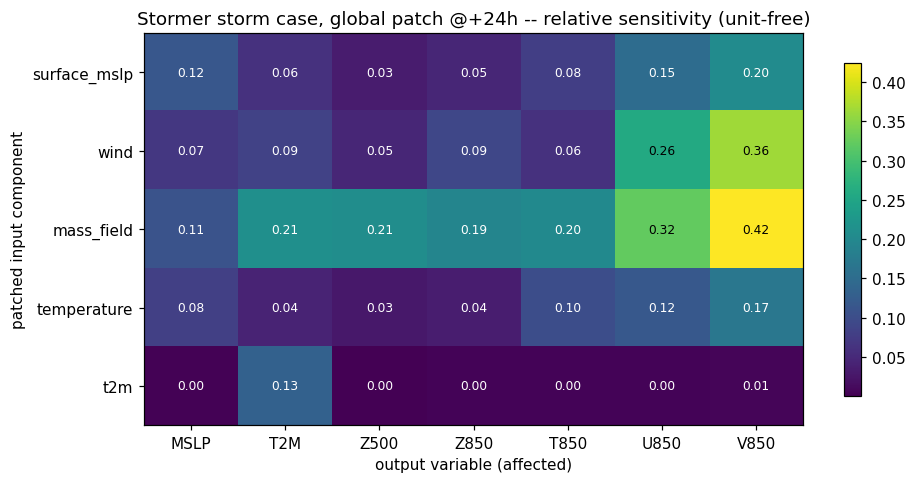

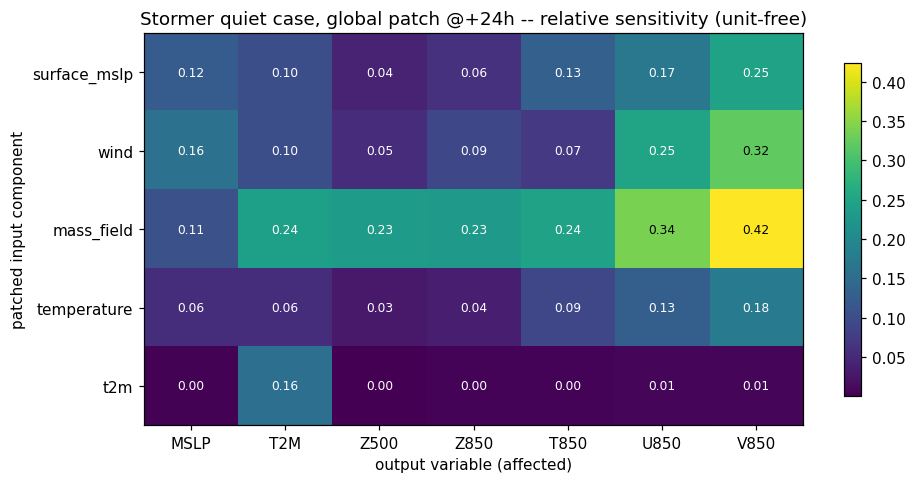

In [2]:
def plot_sensitivity_matrix(date_label, scope, metric_col, title, cmap='viridis', fmt='{:.2f}'):
    sub = df[(df.date == date_label) & (df.scope == scope) & (df.lead_hours == 24)]
    mat = sub.pivot(index='component', columns='var', values=metric_col).reindex(
        index=COMPONENTS, columns=CORE_VARS)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    im = ax.imshow(mat.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(CORE_VARS)))
    ax.set_xticklabels(CORE_VARS)
    ax.set_yticks(range(len(COMPONENTS)))
    ax.set_yticklabels(COMPONENTS)
    ax.set_xlabel('output variable (affected)')
    ax.set_ylabel('patched input component')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, fmt.format(mat.values[i, j]), ha='center', va='center',
                     color='white' if mat.values[i, j] < np.nanmax(mat.values) * 0.6 else 'black', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(title)
    plt.tight_layout()
    safe = title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace(',', '')
    plt.savefig(f'{FIG_DIR}/{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_sensitivity_matrix('storm', 'global', 'metric4_relative_sensitivity',
                         'Stormer storm case, global patch @+24h -- relative sensitivity (unit-free)')
plot_sensitivity_matrix('quiet', 'global', 'metric4_relative_sensitivity',
                         'Stormer quiet case, global patch @+24h -- relative sensitivity (unit-free)')

Rows = which input component was replaced by climatology; columns = which output variable's
forecast changed as a result (relative to std of that variable's own truth field, so units
cancel and rows/columns are comparable). Diagonal-ish structure (each component most strongly
affecting its "own" physical variable) would indicate mostly local effects; strong off-diagonal
entries (e.g. `surface_mslp` affecting `Z500`/`Z850`) indicate the model enforces physical
coupling between fields (mass-wind balance) rather than treating each variable independently.

## 2. Does patching make the forecast worse? (ΔRMSE vs ground truth)

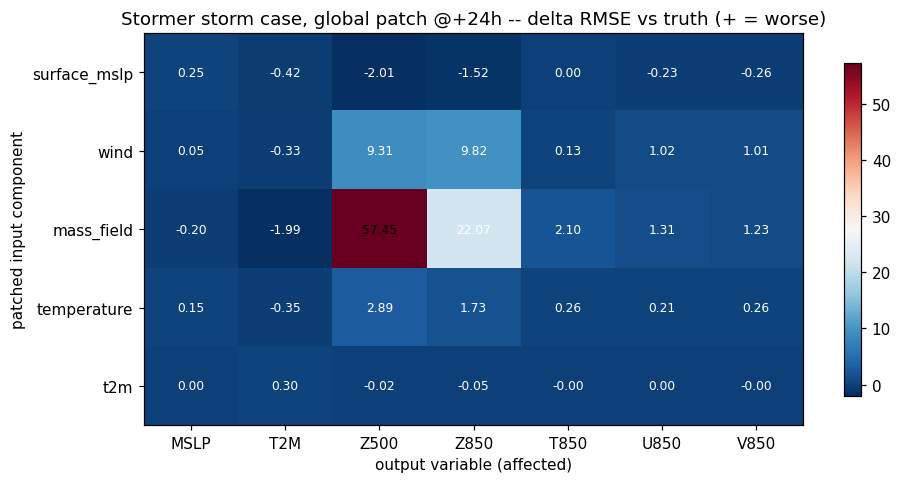

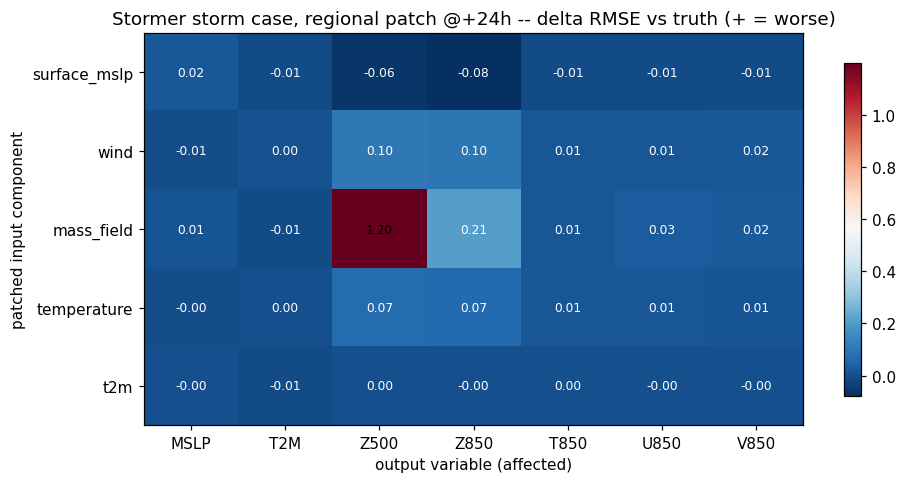

In [3]:
plot_sensitivity_matrix('storm', 'global', 'metric2_delta_rmse_vs_truth',
                         'Stormer storm case, global patch @+24h -- delta RMSE vs truth (+ = worse)', cmap='RdBu_r')
plot_sensitivity_matrix('storm', 'regional', 'metric2_delta_rmse_vs_truth',
                         'Stormer storm case, regional patch @+24h -- delta RMSE vs truth (+ = worse)', cmap='RdBu_r')

Positive (red) = patching that component made the forecast *less accurate* against ERA5
ground truth (regridded to Stormer's 128x256 grid) for that output variable -- direct evidence
the model actually needed that real input information to get the storm right, not just that the
forecast changed.

## 3. Sensitivity vs lead time

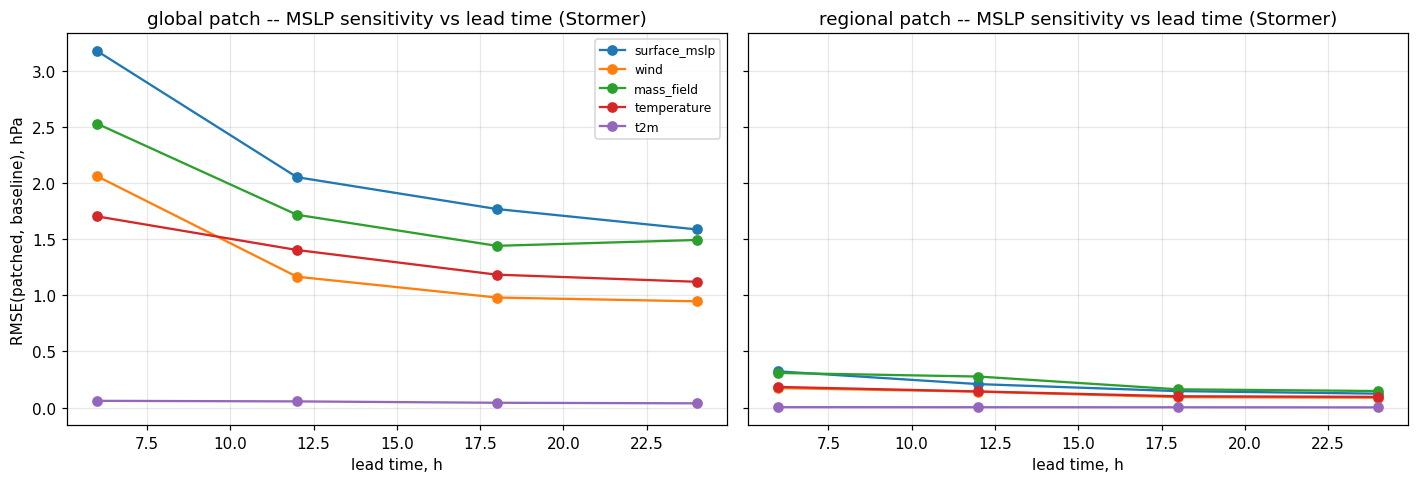

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, scope in zip(axes, ['global', 'regional']):
    for component in COMPONENTS:
        sub = df[(df.date == 'storm') & (df.scope == scope) & (df.component == component) & (df['var'] == 'MSLP')]
        sub = sub.sort_values('lead_hours')
        ax.plot(sub.lead_hours, sub.metric1_rmse_patch_baseline, marker='o', label=component)
    ax.set_xlabel('lead time, h')
    ax.set_title(f'{scope} patch -- MSLP sensitivity vs lead time (Stormer)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('RMSE(patched, baseline), hPa')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/sensitivity_vs_leadtime_MSLP.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Storm-focused weighted RMSE vs plain area-weighted (storm case only)

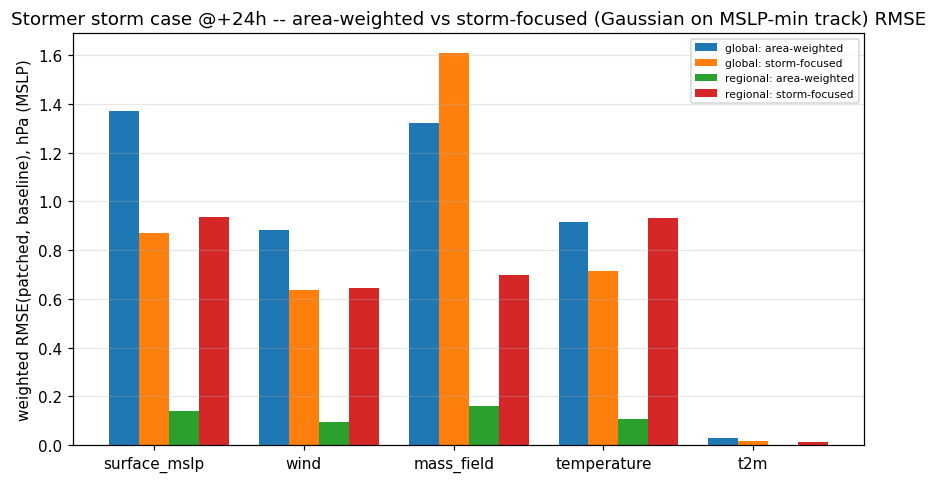

In [5]:
sub = df[(df.date == 'storm') & (df.lead_hours == 24) & (df['var'] == 'MSLP')]
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(COMPONENTS))
width = 0.2
for i, scope in enumerate(['global', 'regional']):
    s = sub[sub.scope == scope].set_index('component').reindex(COMPONENTS)
    ax.bar(x + (i - 0.5) * width * 2, s['weighted_rmse_area'], width, label=f'{scope}: area-weighted')
    ax.bar(x + (i - 0.5) * width * 2 + width, s['weighted_rmse_storm'], width, label=f'{scope}: storm-focused')
ax.set_xticks(x)
ax.set_xticklabels(COMPONENTS)
ax.set_ylabel('weighted RMSE(patched, baseline), hPa (MSLP)')
ax.set_title('Stormer storm case @+24h -- area-weighted vs storm-focused (Gaussian on MSLP-min track) RMSE')
ax.legend(fontsize=7)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/weighted_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

If storm-focused (Gaussian-on-track) weighting gives a *larger* value than plain
area-weighting for a given component, that component's influence is concentrated right at the
storm rather than spread evenly across the domain -- i.e. removing real information about that
component specifically hurts the storm forecast, not just the forecast in general. Note the
Gaussian sigma=5deg is applied on Stormer's coarser 128x256 grid (~1.4deg spacing), so it spans
roughly 3-4 grid cells rather than the ~20 cells it would span on Aurora's native grid.

## 5. Error maps: baseline vs truth, patched vs truth, patched vs baseline (+24h, China zoom)

/home/prokhor/venv/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


/home/prokhor/venv/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


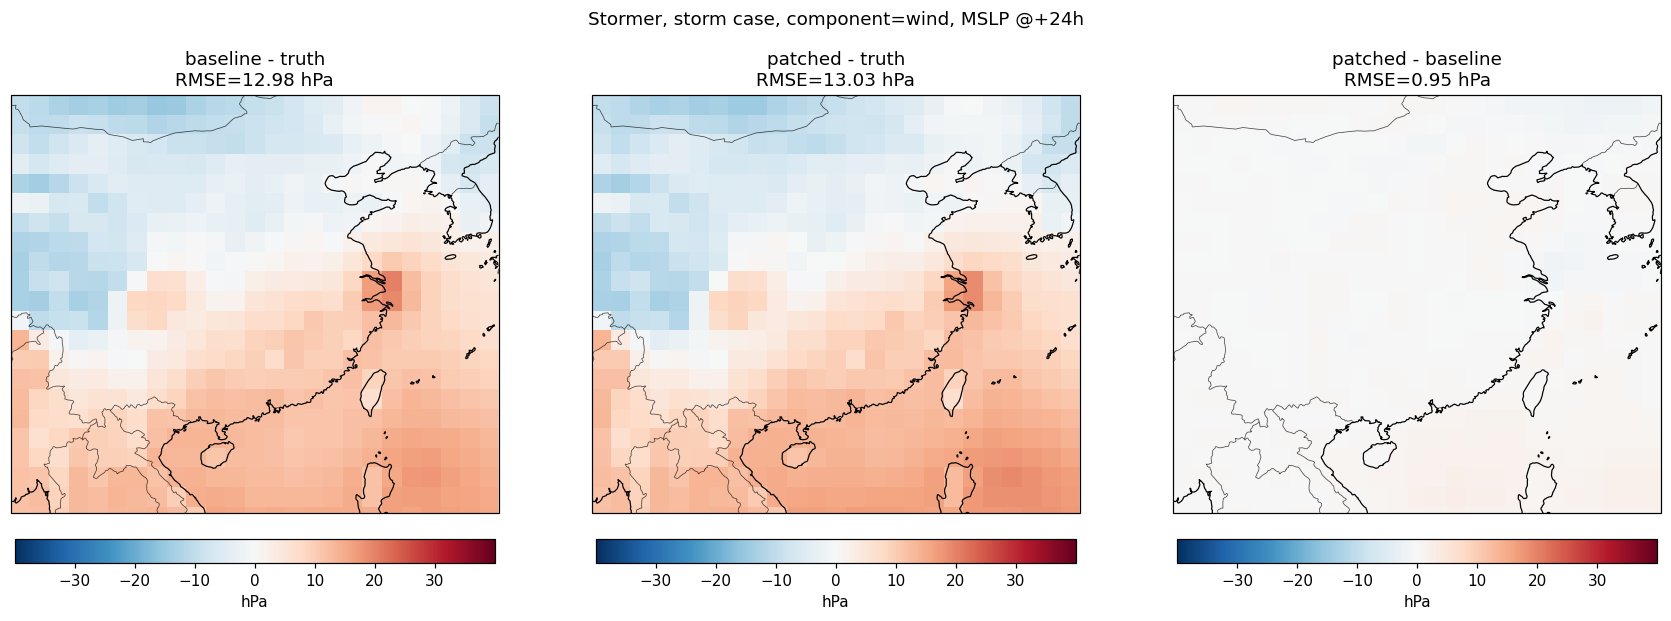

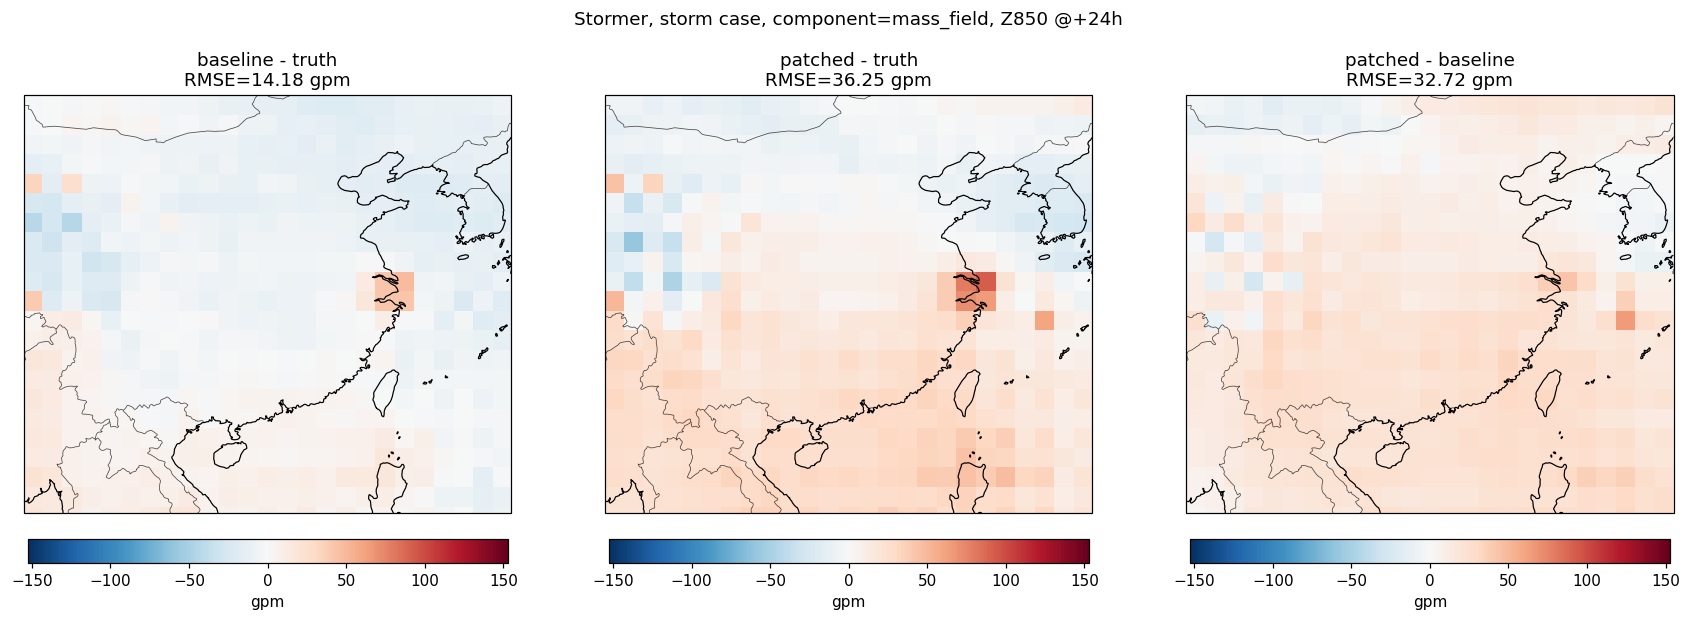

In [6]:
def plot_error_maps(date_label, var_label, component):
    d = maps[(date_label, var_label, component)]
    truth, baseline, patched, unit = d['truth'], d['baseline'], d['patched'], d['unit']
    lat, lon = lat_full, lon_full
    panels = [
        ('baseline - truth', baseline - truth),
        ('patched - truth', patched - truth),
        ('patched - baseline', patched - baseline),
    ]
    vmax = np.nanmax(np.abs([p[1] for p in panels])) * 0.8
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), subplot_kw={'projection': ccrs.PlateCarree()})
    for ax, (title, field) in zip(axes, panels):
        ax.set_extent(CHINA_EXTENT, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
        im = ax.pcolormesh(lon, lat, field, transform=ccrs.PlateCarree(), cmap='RdBu_r',
                            vmin=-vmax, vmax=vmax)
        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.85, label=unit)
        rmse = np.sqrt(np.nanmean(field ** 2))
        ax.set_title(f'{title}\nRMSE={rmse:.2f} {unit}')
    fig.suptitle(f'Stormer, {date_label} case, component={component}, {var_label} @+24h', y=1.03)
    plt.tight_layout()
    safe = f'{date_label}_{component}_{var_label}'
    plt.savefig(f'{FIG_DIR}/errormaps_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_error_maps('storm', 'MSLP', 'wind')
plot_error_maps('storm', 'Z850', 'mass_field')

## Summary

- Metric 4 (relative sensitivity matrix) shows which input components Stormer leans on for
  each output variable, and whether that coupling is mostly diagonal (self-variable) or
  cross-variable (physical balance enforced internally).
- Metric 2 (ΔRMSE vs truth) is the most direct causal claim: it tells us whether removing real
  information about a component actually degrades forecast *accuracy*, not just shifts the
  forecast away from baseline.
- The storm-focused weighted RMSE (Section 4) lets us tell apart "this component matters
  everywhere" from "this component specifically matters for the typhoon."
- Unlike Aurora (two-timestep input, autoregressive rollout, native 0.25deg), Stormer here uses
  a single-timestep input, a direct per-lead-time forward pass, and a coarser regridded
  1.40625deg (128x256) grid -- so absolute error magnitudes are not comparable pixel-for-pixel
  against the Aurora notebook, only the qualitative sensitivity patterns are.
- All raw model outputs (baseline + every patched variant, both dates) are cached in
  `results/patching_experiment_stormer/*.npz`, and the derived per-variable/lead-time metrics
  table in `results/patching_experiment_stormer/metrics_summary.pkl`, so further slicing doesn't
  require rerunning Stormer.